# 06 — Viralization and Temporal Analysis

Quantitative analysis of narrative spread and temporal dynamics. We correlate semantic metrics with engagement data (views and forwards) to identify patterns of viral disinformation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

val_df = pd.read_csv('validation_results.csv')
full_df = pd.read_csv('aletheia_filtered.csv')

# Analysis restricted to validated disinformation subset
disinfo_df = val_df[val_df['classification'] == 'SUPPORTS'].copy()

df_final = disinfo_df.merge(full_df[['views', 'n_forwards', 'date']], 
                            left_on='msg_idx', right_index=True)

df_final['date'] = pd.to_datetime(df_final['date'])
print(f"Analyzing {len(df_final)} validated instances.")

Analyzing 97 validated instances.


### 1. Narrative Impact

/var/folders/bq/zx968mhx0q3_ky0182s0bvc80000gp/T/ipykernel_54998/1327288023.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_final, x='n_forwards', y='narrative', ax=axes[0], palette='viridis')
/var/folders/bq/zx968mhx0q3_ky0182s0bvc80000gp/T/ipykernel_54998/1327288023.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_final, x='views', y='narrative', ax=axes[1], palette='magma')


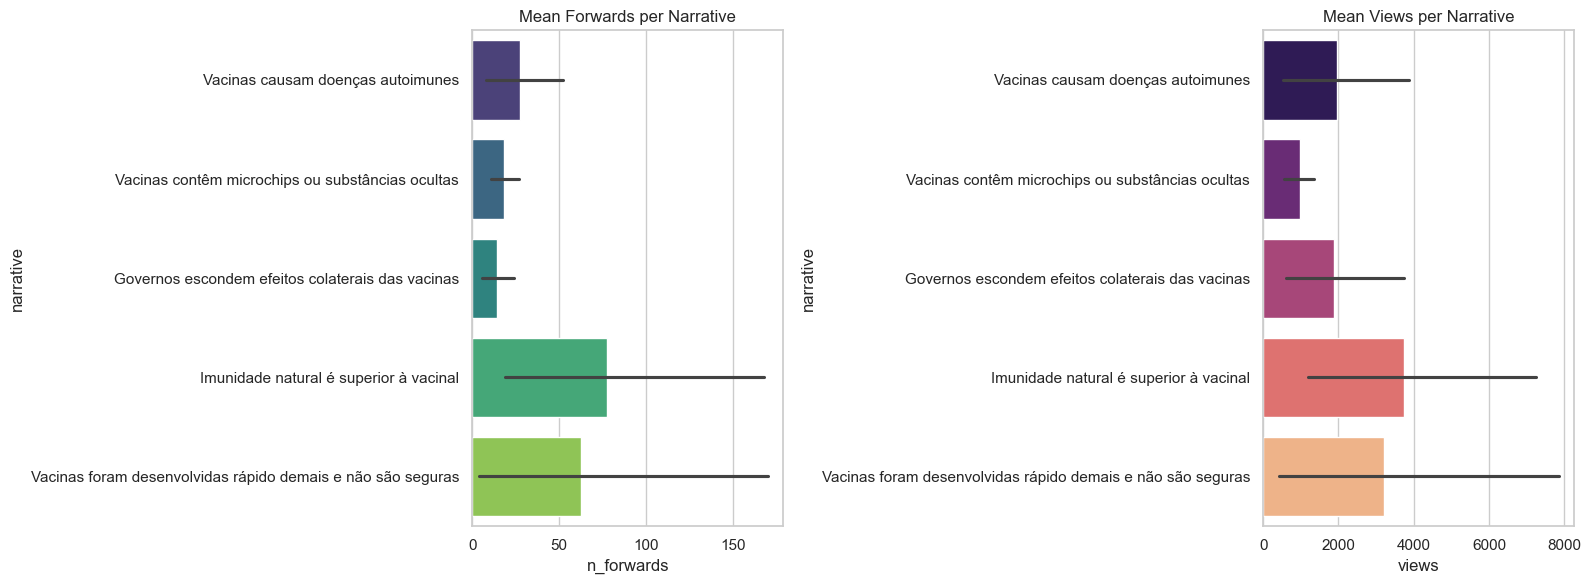

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=df_final, x='n_forwards', y='narrative', ax=axes[0], palette='viridis')
axes[0].set_title('Mean Forwards per Narrative')

sns.barplot(data=df_final, x='views', y='narrative', ax=axes[1], palette='magma')
axes[1].set_title('Mean Views per Narrative')

plt.tight_layout()
plt.show()

### 2. Semantic Centrality vs. Engagement

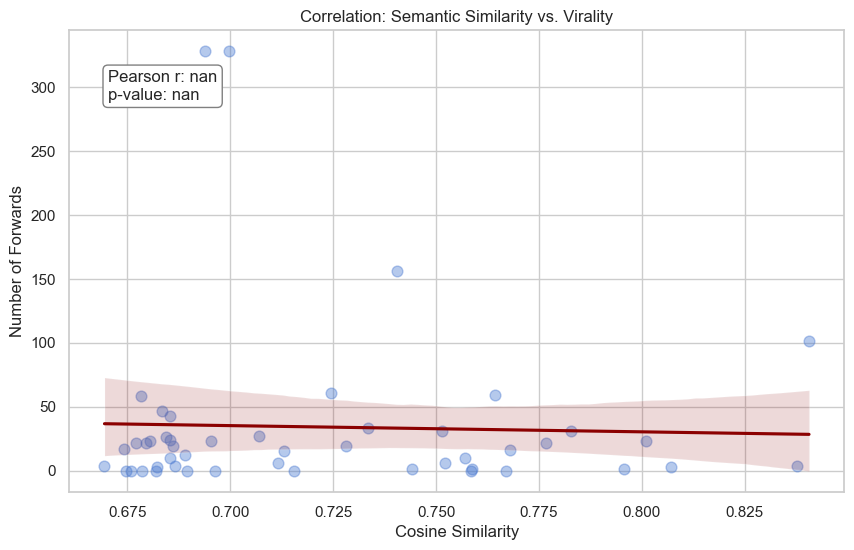

In [3]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df_final, x='cosine_score', y='n_forwards', 
            scatter_kws={'alpha':0.4, 's':60}, line_kws={'color':'darkred'})

plt.title('Correlation: Semantic Similarity vs. Virality')
plt.xlabel('Cosine Similarity')
plt.ylabel('Number of Forwards')

r, p = pearsonr(df_final['cosine_score'], df_final['n_forwards'])
plt.annotate(f'Pearson r: {r:.3f}\np-value: {p:.4f}', 
             xy=(0.05, 0.85), xycoords='axes fraction', bbox=dict(boxstyle="round", fc="w", ec="0.5"))
plt.show()

### 3. Temporal Dynamics

/Users/danielesouza/Desktop/Mesa - MacBook Pro de Daniele/Unicamp/MO850/final_project/venv/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1613: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)
/Users/danielesouza/Desktop/Mesa - MacBook Pro de Daniele/Unicamp/MO850/final_project/venv/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1613: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)
/Users/danielesouza/Desktop/Mesa - MacBook Pro de Daniele/Unicamp/MO850/final_project/venv/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1613: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)
/Users/danielesouza/Desktop/Mesa - MacBook Pro de Daniele/Unicamp/MO850/final_project

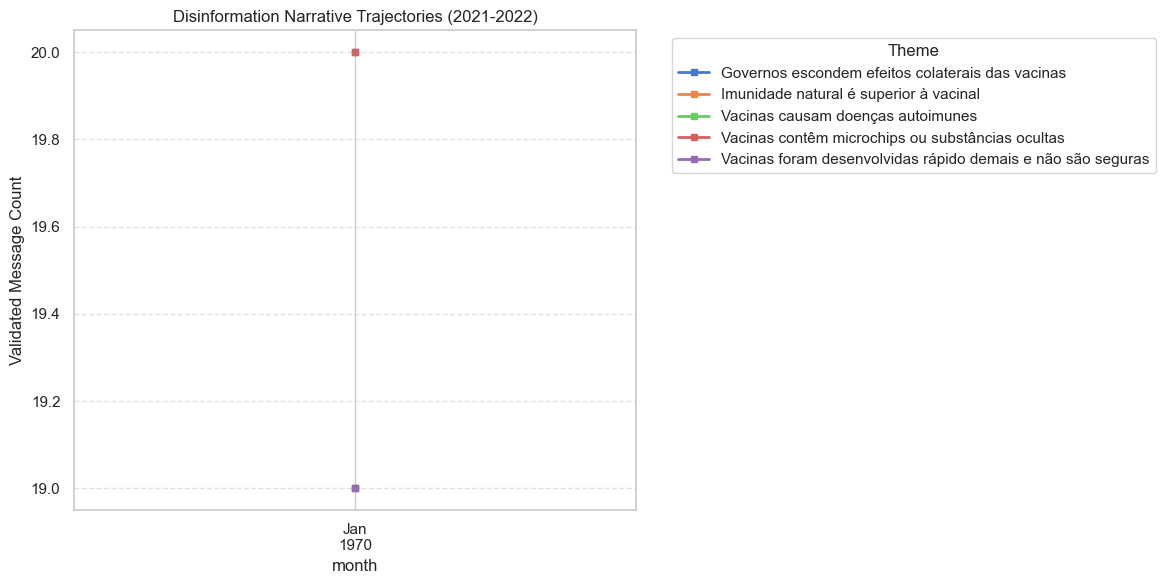

In [4]:
df_final['month'] = df_final['date'].dt.to_period('M')
evolution = df_final.groupby(['month', 'narrative']).size().unstack(fill_value=0)

evolution.plot(kind='line', marker='s', markersize=4, linewidth=2)
plt.title('Disinformation Narrative Trajectories (2021-2022)')
plt.ylabel('Validated Message Count')
plt.legend(title='Theme', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Metrics Summary

In [5]:
summary = df_final.groupby('narrative').agg({
    'n_forwards': ['mean', 'std', 'max'],
    'views': 'mean',
    'cosine_score': 'mean'
})
summary.columns = ['Avg Forwards', 'Std Forwards', 'Max Forwards', 'Avg Views', 'Avg Semantic Score']
summary.sort_values('Avg Forwards', ascending=False).style.background_gradient(cmap='YlOrRd')

,Avg Forwards,Std Forwards,Max Forwards,Avg Views,Avg Semantic Score
narrative,,,,,
Imunidade natural é superior à vacinal,77.625000,112.692930,328.000000,3744.375000,0.705369
Vacinas foram desenvolvidas rápido demais e não são seguras,62.333333,130.519986,328.000000,3219.000000,0.694764
Vacinas causam doenças autoimunes,27.625000,36.094865,101.000000,1959.250000,0.696240
Vacinas contêm microchips ou substâncias ocultas,18.307692,15.304600,47.000000,966.538462,0.693791
Governos escondem efeitos colaterais das vacinas,14.230769,17.602812,59.000000,1876.923077,0.772441
